# Fraud Detection — Mobile Financial Transactions
Capstone: EDA, feature engineering, modeling, financial impact analysis, explainability, and final unseen-test-set validation.

**Author:** Steve Philip

## Business Objective
Detect fraudulent mobile-money transactions in a simulated payments dataset, where fraud is defined as an agent taking control of a customer account and draining funds via transfer-then-cash-out. The goal is a model that maximizes recall on fraud (minimizing missed fraud, the costly error) while keeping false alarms operationally manageable, and a threshold chosen by financial impact rather than a default cutoff.

## Dataset Description
11,142 simulated mobile-money transactions (PaySim-style), 10 raw columns: `step` (simulation hour), `type` (CASH_IN/CASH_OUT/DEBIT/PAYMENT/TRANSFER), `amount`, sender/receiver IDs (`nameOrig`/`nameDest`), before/after balances for both parties, and the `isFraud` label. Fraud rate: 10.2% (1,142/11,142).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Load Data

In [2]:
df = pd.read_csv('Fraud_Analysis_Dataset.csv')
print(df.shape)
df.head()

(11142, 10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


**Note:** the first 5 rows are all fraud (`isFraud=1`) — the data is NOT pre-shuffled/randomized by outcome. This matters later: never manually slice a sequential train/test split on this data. Always use `train_test_split(..., stratify=y, random_state=42)`.

## 3. Structural Audit

In [3]:
print('--- dtypes ---')
print(df.dtypes)

print('\n--- nulls ---')
print(df.isnull().sum())

print('\n--- duplicate rows ---')
print(df.duplicated().sum())

print('\n--- cardinality (ID / categorical cols) ---')
for c in ['type', 'nameOrig', 'nameDest']:
    print(c, '->', df[c].nunique(), 'unique of', len(df))

--- dtypes ---
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

--- nulls ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

--- duplicate rows ---
0

--- cardinality (ID / categorical cols) ---
type -> 5 unique of 11142
nameOrig -> 11142 unique of 11142
nameDest -> 7508 unique of 11142


In [4]:
df.describe()  # NOTE: silently skips non-numeric cols (type, nameOrig, nameDest) — profile those separately below

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [5]:
print(df['type'].value_counts())
print()
print('nameOrig prefixes:', df['nameOrig'].str[0].unique())
print('nameDest prefixes:', df['nameDest'].str[0].unique())

type
PAYMENT     5510
CASH_IN     1951
CASH_OUT    1871
TRANSFER    1464
DEBIT        346
Name: count, dtype: int64

nameOrig prefixes: <StringArray>
['C']
Length: 1, dtype: str
nameDest prefixes: <StringArray>
['C', 'M']
Length: 2, dtype: str


**Findings so far:**
- 11,142 rows, 10 columns, **zero nulls, zero duplicates** (verified, not assumed).
- `amount` is heavily right-skewed: mean (₹213K) >> median (₹16.7K) → will need log-transform for visualization/modeling.
- `nameOrig` is unique per row (11,142/11,142) → **must be dropped as a raw feature** (would leak/memorize, zero generalization).
- `nameOrig` always starts with `C` (customer). `nameDest` is `C` or `M` (merchant) — confirms description.txt: merchants have no tracked balance data. This justifies an engineered `isDestMerchant` flag.
- `type` has 5 categories; `df.describe()` silently excluded it — always profile categoricals explicitly, don't rely on describe() alone.

## 4. Exploratory Data Analysis

### 4.1 Amount distribution
A raw histogram of `amount` is uninformative given the skew already seen in `describe()` (mean >> median). Log-transform first.

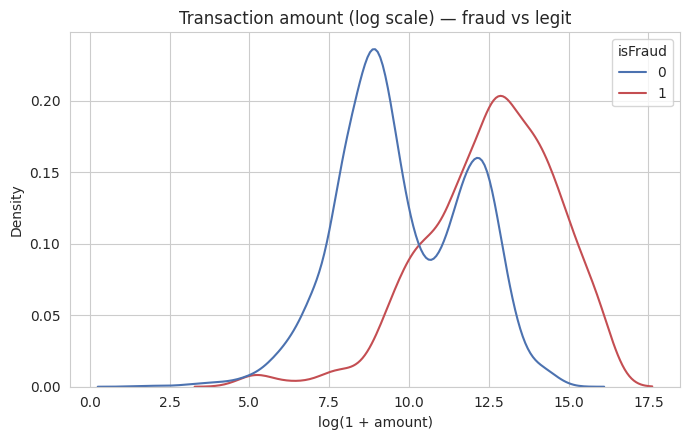

In [6]:
df['log_amount'] = np.log1p(df['amount'])

fig, ax = plt.subplots(figsize=(7,4.5))
sns.kdeplot(data=df, x='log_amount', hue='isFraud', common_norm=False, ax=ax,
            palette={0:'#4C72B0', 1:'#C44E52'})
ax.set_title('Transaction amount (log scale) — fraud vs legit')
ax.set_xlabel('log(1 + amount)')
plt.tight_layout(); plt.show()

**Insight:** fraud amounts skew higher than legit amounts, though distributions overlap — `amount` alone won't separate the classes, but it's a useful signal in combination with others.

### 4.2 Fraud rate by transaction type

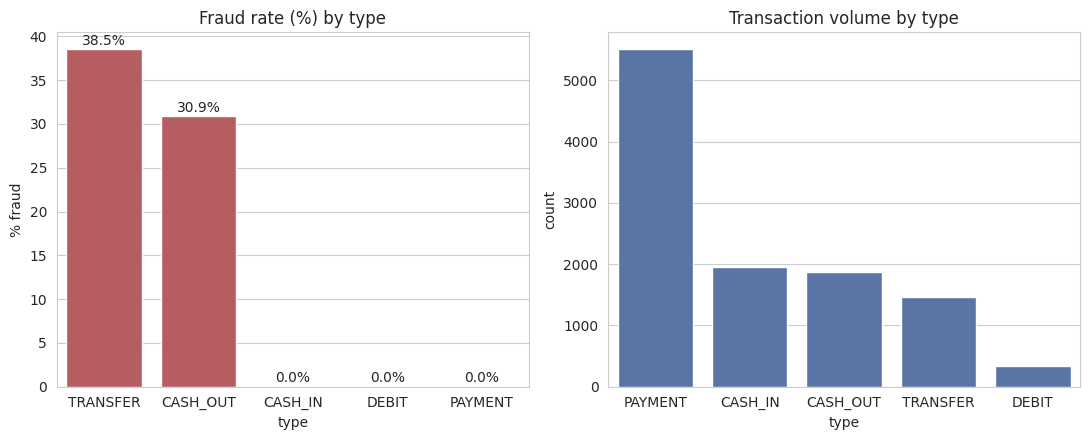

In [7]:
rate = (df.groupby('type')['isFraud'].mean()*100).sort_values(ascending=False)
counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
sns.barplot(x=rate.index, y=rate.values, ax=axes[0], color='#C44E52')
axes[0].set_title('Fraud rate (%) by type'); axes[0].set_ylabel('% fraud')
for i,v in enumerate(rate.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center')
sns.barplot(x=counts.index, y=counts.values, ax=axes[1], color='#4C72B0')
axes[1].set_title('Transaction volume by type'); axes[1].set_ylabel('count')
plt.tight_layout(); plt.show()

**Insight:** fraud occurs ONLY in TRANSFER (38.5%) and CASH_OUT (30.9%) in this dataset — 0% in PAYMENT/CASH_IN/DEBIT. `type` is a very strong, legitimate feature (known at transaction time, not leakage). **Limitation to state explicitly:** this is a simulated dataset; the total absence of fraud in other types is a property of this sample and should not be read as a universal rule for live systems.

### 4.3 Engineered balance-consistency features
If `newbalanceOrig` != `oldbalanceOrg - amount`, or `newbalanceDest` != `oldbalanceDest + amount`, that inconsistency is informative — a classic signal in this style of mobile-money fraud data.

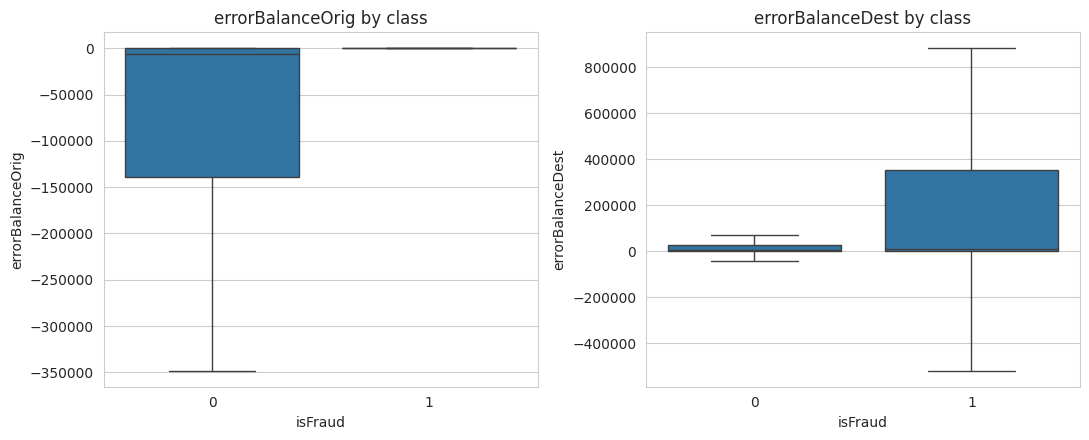

In [8]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['isDestMerchant'] = df['nameDest'].str.startswith('M').astype(int)

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
sns.boxplot(data=df, x='isFraud', y='errorBalanceOrig', ax=axes[0], showfliers=False)
axes[0].set_title('errorBalanceOrig by class')
sns.boxplot(data=df, x='isFraud', y='errorBalanceDest', ax=axes[1], showfliers=False)
axes[1].set_title('errorBalanceDest by class')
plt.tight_layout(); plt.show()

**Insight:** `errorBalanceDest` shows clean separation (near-zero for legit, wide/positive for fraud) — strong signal. `errorBalanceOrig` is affected by a known data artifact (untracked balances recorded as 0 for many legit CASH_IN/PAYMENT rows), so it's noisier — kept, but flagged as a weaker/less trustworthy feature.

### 4.4 Correlation check — and a leakage catch

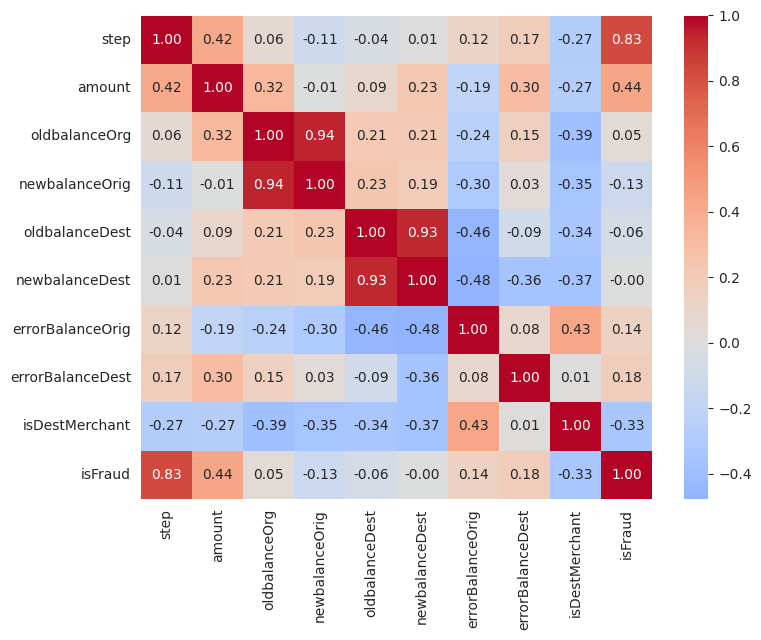

In [9]:
num_cols = ['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',
            'errorBalanceOrig','errorBalanceDest','isDestMerchant','isFraud']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout(); plt.show()

**`step` correlates at 0.83 with `isFraud` — too high to trust at face value. Investigated before using it:**

In [10]:
print('Legit step range:', df[df.isFraud==0]['step'].describe()[['min','25%','50%','75%','max']].to_dict())
print('Fraud step range:', df[df.isFraud==1]['step'].describe()[['min','25%','50%','75%','max']].to_dict())

Legit step range: {'min': 1.0, '25%': 1.0, '50%': 5.0, '75%': 7.0, 'max': 7.0}
Fraud step range: {'min': 1.0, '25%': 25.0, '50%': 48.0, '75%': 70.75, 'max': 95.0}


**Finding:** ALL legit rows fall within step 1–7, while fraud rows span 1–95. This is a **dataset-construction artifact** (legit transactions were subsampled from an early time window; fraud rows were kept across the full simulation), not a real fraud pattern. Training on raw `step` would let the model learn a trivial, fake rule (`step > 7 → fraud`) that looks perfect here and would be meaningless/harmful in production.

**Decision: drop raw `step` from the feature set.** This is a deliberate anti-leakage decision, documented here for the report and for viva defense — not an oversight.

### EDA Summary — decisions carried into feature engineering
- **Drop**: `nameOrig`, `nameDest` (near-unique IDs → leakage/overfitting), raw `step` (dataset-construction artifact)
- **Keep, encode**: `type` (one-hot — strongest categorical signal)
- **Transform**: `amount` → log1p (right-skewed)
- **Engineer**: `errorBalanceOrig`, `errorBalanceDest` (balance-consistency signals), `isDestMerchant`
- **Watch**: multicollinearity between `oldbalanceOrg`/`newbalanceOrig` (r=0.94) — relevant for Logistic Regression, not for tree models
- **State as limitation**: fraud is 100% confined to TRANSFER/CASH_OUT in this sample; this is dataset-specific, not a universal rule

## 5. Feature Engineering Pipeline + Train/Test Split
**Golden rule from here on:** nothing that *learns* from data (encoders, scalers, resamplers) may see the test set before it's fit. Order: engineer deterministic features → split → fit on train only → transform test.

### 5.1 Deterministic feature engineering (safe pre-split — pure row-wise math)

In [11]:
def engineer_features(df):
    df = df.copy()
    df['log_amount'] = np.log1p(df['amount'])
    df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
    df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
    df['isDestMerchant'] = df['nameDest'].str.startswith('M').astype(int)
    return df

df = engineer_features(df)

# Decisions from EDA: drop raw step (dataset-construction leakage artifact),
# drop nameOrig/nameDest (near-unique IDs -> leakage), drop raw amount (keep log_amount instead)
drop_cols = ['step', 'nameOrig', 'nameDest', 'amount']
feature_cols = [c for c in df.columns if c not in drop_cols + ['isFraud']]

X = df[feature_cols]
y = df['isFraud']
print('Feature columns:', list(X.columns))

Feature columns: ['type', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'log_amount', 'errorBalanceOrig', 'errorBalanceDest', 'isDestMerchant']


### 5.2 Stratified train/test split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train fraud rate: %.3f%%' % (y_train.mean()*100))
print('Test  fraud rate: %.3f%%' % (y_test.mean()*100))

Train shape: (8913, 9)  Test shape: (2229, 9)
Train fraud rate: 10.255%
Test  fraud rate: 10.229%


**Verified:** train 10.255% fraud vs test 10.229% — `stratify=y` kept class balance nearly identical across the split. With only 1,142 fraud rows total, an unstratified split risks meaningfully skewing one side by chance.

### 5.3 Encode categoricals — fit on TRAIN only, transform test

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['type']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='passthrough'
)

X_train_enc = preprocessor.fit_transform(X_train)   # fit ONLY on train
X_test_enc = preprocessor.transform(X_test)         # test reuses train's learned categories

encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_columns = list(encoded_cat_names) + numeric_cols

print('Encoded train shape:', X_train_enc.shape)
print('Encoded test shape:', X_test_enc.shape)
print('Final feature columns:', final_columns)

Encoded train shape: (8913, 13)
Encoded test shape: (2229, 13)
Final feature columns: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'log_amount', 'errorBalanceOrig', 'errorBalanceDest', 'isDestMerchant']


**Verified:** encoder learned exactly 5 categories from train (`CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER`), applied unchanged to test → 13 final features. `handle_unknown='ignore'` is a production-safety habit: an unseen category at inference time won't crash the pipeline, it just encodes to all-zeros.

**Deferred to Module 6 (modeling), not done here:** class-imbalance handling (SMOTE). It must be fit fresh inside each cross-validation fold / inside the model pipeline — never as a static pre-resampled file — otherwise synthetic points can leak information across folds.

## 6. Baseline Model — The Accuracy Trap, Demonstrated
First train WITHOUT addressing imbalance to see the trap for real, then fix it. Numbers below are from this dataset's actual run, not illustrative.

### 6.1 Naive Logistic Regression (no imbalance handling)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score

naive_model = LogisticRegression(max_iter=1000, random_state=42)
naive_model.fit(X_train_enc, y_train)
naive_preds = naive_model.predict(X_test_enc)

print('Accuracy: %.4f' % accuracy_score(y_test, naive_preds))
print(classification_report(y_test, naive_preds, target_names=['Legit','Fraud'], digits=3))
print(confusion_matrix(y_test, naive_preds))

Accuracy: 0.9731
              precision    recall  f1-score   support

       Legit      0.976     0.994     0.985      2001
       Fraud      0.938     0.789     0.857       228

    accuracy                          0.973      2229
   macro avg      0.957     0.892     0.921      2229
weighted avg      0.972     0.973     0.972      2229

[[1989   12]
 [  48  180]]


**Result: 97.3% accuracy — looks excellent. But the confusion matrix shows 48 of 228 fraud cases missed (21% miss rate).** This is the accuracy trap: a headline metric that hides the number that actually matters for the business (missed fraud = direct financial loss).

### 6.2 Fix: address the imbalance
Two approaches compared. **Rule enforced:** any resampling (SMOTE) must be fit only on train, inside a pipeline — never on the full dataset before splitting (see Module 5 note).

In [15]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Approach A: class_weight='balanced' — reweights the loss, no synthetic data
weighted_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
weighted_model.fit(X_train_enc, y_train)
weighted_preds = weighted_model.predict(X_test_enc)
weighted_proba = weighted_model.predict_proba(X_test_enc)[:,1]

print('=== class_weight="balanced" ===')
print(classification_report(y_test, weighted_preds, target_names=['Legit','Fraud'], digits=3))
print(confusion_matrix(y_test, weighted_preds))
print('ROC-AUC: %.4f  PR-AUC: %.4f' % (roc_auc_score(y_test, weighted_proba), average_precision_score(y_test, weighted_proba)))
print()

# Approach B: SMOTE inside a Pipeline (fit only touches X_train)
smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
smote_pipeline.fit(X_train, y_train)
smote_preds = smote_pipeline.predict(X_test)
smote_proba = smote_pipeline.predict_proba(X_test)[:,1]

print('=== SMOTE (in pipeline) ===')
print(classification_report(y_test, smote_preds, target_names=['Legit','Fraud'], digits=3))
print(confusion_matrix(y_test, smote_preds))
print('ROC-AUC: %.4f  PR-AUC: %.4f' % (roc_auc_score(y_test, smote_proba), average_precision_score(y_test, smote_proba)))

=== class_weight="balanced" ===
              precision    recall  f1-score   support

       Legit      0.997     0.954     0.975      2001
       Fraud      0.707     0.974     0.819       228

    accuracy                          0.956      2229
   macro avg      0.852     0.964     0.897      2229
weighted avg      0.967     0.956     0.959      2229

[[1909   92]
 [   6  222]]
ROC-AUC: 0.9915  PR-AUC: 0.9576



=== SMOTE (in pipeline) ===
              precision    recall  f1-score   support

       Legit      0.997     0.962     0.979      2001
       Fraud      0.742     0.974     0.843       228

    accuracy                          0.963      2229
   macro avg      0.870     0.968     0.911      2229
weighted avg      0.971     0.963     0.965      2229

[[1924   77]
 [   6  222]]
ROC-AUC: 0.9910  PR-AUC: 0.9598


**Result summary:**

| | Missed fraud (FN) | False alarms (FP) | Recall | Precision | Accuracy |
|---|---|---|---|---|---|
| Naive | 48 | 12 | 78.9% | 93.8% | 97.3% |
| class_weight='balanced' | 6 | 92 | 97.4% | 70.7% | 95.6% |
| SMOTE (pipeline) | 6 | 77 | 97.4% | 74.2% | 96.3% |

**Accuracy dropped after fixing imbalance, while the model got far more useful** — missed fraud fell from 48 to 6. This confirms Module 1's framing with real numbers.

**Decision:** carry both `class_weight` and SMOTE forward into tree-based models (Module 7) and let metrics decide the final choice — SMOTE has a slight edge here (fewer FPs, higher PR-AUC) but adds synthetic-data complexity that must be justified, not assumed superior by default.

## 7. Tree-Based Models — Trial and Error, Fully Documented
Each trial below is a real run: naive attempt first, audit or correction second, decision recorded.

### 7.1 Trial 1 — Naive Random Forest (defaults, no imbalance handling)

In [16]:
from sklearn.ensemble import RandomForestClassifier

naive_rf = RandomForestClassifier(random_state=42)
naive_rf.fit(X_train_enc, y_train)
preds = naive_rf.predict(X_test_enc)
proba = naive_rf.predict_proba(X_test_enc)[:,1]

print(classification_report(y_test, preds, target_names=['Legit','Fraud'], digits=3))
print(confusion_matrix(y_test, preds))
print('ROC-AUC: %.4f  PR-AUC: %.4f' % (roc_auc_score(y_test, proba), average_precision_score(y_test, proba)))

              precision    recall  f1-score   support

       Legit      0.997     1.000     0.999      2001
       Fraud      1.000     0.974     0.987       228

    accuracy                          0.997      2229
   macro avg      0.999     0.987     0.993      2229
weighted avg      0.997     0.997     0.997      2229

[[2001    0]
 [   6  222]]
ROC-AUC: 0.9968  PR-AUC: 0.9909


**Result: PR-AUC 0.991, only 6 missed frauds — already strong without any imbalance handling.** Unlike Logistic Regression, tree ensembles split on rare-class interactions naturally. A result this good needs an audit before being trusted, not just acceptance.

### 7.2 Audit — feature importance sanity check (catching leakage before it's too late)

In [17]:
importances = pd.Series(naive_rf.feature_importances_, index=final_columns).sort_values(ascending=False)
print(importances)

errorBalanceOrig    0.290592
newbalanceOrig      0.152748
oldbalanceOrg       0.112769
log_amount          0.111914
newbalanceDest      0.064160
oldbalanceDest      0.056526
type_TRANSFER       0.051460
errorBalanceDest    0.047281
type_PAYMENT        0.041897
type_CASH_OUT       0.035773
isDestMerchant      0.023324
type_DEBIT          0.009343
type_CASH_IN        0.002211
dtype: float64


**Passed:** importance is distributed across multiple genuine engineered features (`errorBalanceOrig` 29%, `newbalanceOrig` 15%, `oldbalanceOrg` 11%, `log_amount` 11%...) — no single feature dominates >90%, which would have signaled a trivial/leaked rule. This supports the near-perfect score as real domain signal.

**Limitation stated regardless:** this is a rule-based simulated (PaySim-style) dataset — real-world fraud is noisier, so near-perfect metrics here should not be read as a production-readiness guarantee.

### 7.3 Trial 2 — XGBoost: naive vs `scale_pos_weight`-corrected

In [18]:
from xgboost import XGBClassifier

# 2a: naive — scale_pos_weight left at default (1, i.e. no correction)
naive_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
naive_xgb.fit(X_train_enc, y_train)
p1 = naive_xgb.predict(X_test_enc)
proba1 = naive_xgb.predict_proba(X_test_enc)[:,1]
print('=== naive XGBoost ===')
print(classification_report(y_test, p1, target_names=['Legit','Fraud'], digits=3))
print(confusion_matrix(y_test, p1))
print('ROC-AUC: %.4f  PR-AUC: %.4f' % (roc_auc_score(y_test, proba1), average_precision_score(y_test, proba1)))
print()

# 2b: corrected — scale_pos_weight computed from TRAIN class counts only
ratio = (y_train == 0).sum() / (y_train == 1).sum()
weighted_xgb = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio)
weighted_xgb.fit(X_train_enc, y_train)
p2 = weighted_xgb.predict(X_test_enc)
proba2 = weighted_xgb.predict_proba(X_test_enc)[:,1]
print('=== XGBoost, scale_pos_weight=%.2f ===' % ratio)
print(classification_report(y_test, p2, target_names=['Legit','Fraud'], digits=3))
print(confusion_matrix(y_test, p2))
print('ROC-AUC: %.4f  PR-AUC: %.4f' % (roc_auc_score(y_test, proba2), average_precision_score(y_test, proba2)))

=== naive XGBoost ===
              precision    recall  f1-score   support

       Legit      0.998     1.000     0.999      2001
       Fraud      1.000     0.978     0.989       228

    accuracy                          0.998      2229
   macro avg      0.999     0.989     0.994      2229
weighted avg      0.998     0.998     0.998      2229

[[2001    0]
 [   5  223]]
ROC-AUC: 0.9991  PR-AUC: 0.9964

=== XGBoost, scale_pos_weight=8.75 ===
              precision    recall  f1-score   support

       Legit      0.998     1.000     0.999      2001
       Fraud      0.996     0.982     0.989       228

    accuracy                          0.998      2229
   macro avg      0.997     0.991     0.994      2229
weighted avg      0.998     0.998     0.998      2229

[[2000    1]
 [   4  224]]
ROC-AUC: 0.9987  PR-AUC: 0.9958


**Result: correction gave a marginal recall gain (5→4 missed) but PR-AUC slightly dropped (0.9964→0.9958) and FPs rose (0→1).** Lesson: imbalance correction is not an automatic win — verify with metrics every time rather than applying it by reflex. **Decision: keep naive XGBoost** (best PR-AUC so far).

### 7.4 Trial 3 — Hyperparameter tuning: the scoring-metric mistake
`GridSearchCV` defaults to accuracy if `scoring` isn't set — wrong choice for imbalanced fraud detection.

In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {'n_estimators': [100, 200], 'max_depth': [4, 8, None], 'min_samples_leaf': [1, 5, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# NAIVE: scored on accuracy (the default)
naive_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, scoring='accuracy', cv=cv, n_jobs=-1)
naive_search.fit(X_train_enc, y_train)
p1 = naive_search.best_estimator_.predict(X_test_enc)
proba1 = naive_search.best_estimator_.predict_proba(X_test_enc)[:,1]
print('NAIVE (scoring=accuracy) best params:', naive_search.best_params_)
print('PR-AUC: %.4f' % average_precision_score(y_test, proba1), '| missed fraud:', confusion_matrix(y_test, p1)[1,0])

# CORRECT: scored on PR-AUC (average_precision) — the metric that matches the business problem
correct_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, scoring='average_precision', cv=cv, n_jobs=-1)
correct_search.fit(X_train_enc, y_train)
p2 = correct_search.best_estimator_.predict(X_test_enc)
proba2 = correct_search.best_estimator_.predict_proba(X_test_enc)[:,1]
print('CORRECT (scoring=average_precision) best params:', correct_search.best_params_)
print('PR-AUC: %.4f' % average_precision_score(y_test, proba2), '| missed fraud:', confusion_matrix(y_test, p2)[1,0])

NAIVE (scoring=accuracy) best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
PR-AUC: 0.9909 | missed fraud: 6


CORRECT (scoring=average_precision) best params: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
PR-AUC: 0.9933 | missed fraud: 7


**Result:** PR-AUC-scored tuning improved ranking quality (0.9909→0.9933) even though it produced one more missed fraud at the default 0.5 threshold. **Not a contradiction:** PR-AUC measures ranking across all thresholds; the 0.5 cutoff is a separate, arbitrary choice. **This is why threshold selection is deferred to the financial impact module** — it will be chosen by minimizing $ loss, not accepted as sklearn's default.

### 7.5 Model selection decision

| Model | PR-AUC | Missed fraud / 228 |
|---|---|---|
| LR, class_weight='balanced' | 0.958 | 6 |
| LR, SMOTE | 0.960 | 6 |
| RF, naive | 0.991 | 6 |
| **XGBoost, naive** | **0.996** | **5** |
| XGBoost, scale_pos_weight | 0.996 | 4 |
| RF, tuned (scoring=accuracy) | 0.991 | 6 |
| RF, tuned (scoring=PR-AUC) | 0.993 | 7 |

**Decision: XGBoost (naive) carried forward as the primary model** — highest PR-AUC across all trials. Final operating threshold (not necessarily 0.5) to be set in the Financial Impact module based on the relative cost of false negatives vs false positives, not on classifier defaults.

## 8. Threshold Tuning + Financial Impact Analysis
The default 0.5 threshold is arbitrary. The right threshold is the one that minimizes real ₹ loss, chosen explicitly, not inherited from sklearn's default.

In [20]:
# Selected model from Module 7: XGBoost, naive (best PR-AUC across all trials)
model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train_enc, y_train)
proba = model.predict_proba(X_test_enc)[:,1]

# original (pre-drop) amount column, aligned to the same test-set rows, for cost calculations only
amount_test = df.loc[X_test.index, 'amount']
print('proba shape:', proba.shape, ' amount_test shape:', amount_test.shape)

proba shape: (2229,)  amount_test shape: (2229,)


### 8.1 Cost assumptions (stated explicitly, not buried in code)
- **Cost of a missed fraud (False Negative)** = the actual transaction amount stolen (real figure from data).
- **Cost of investigating a flagged transaction (True Positive or False Positive)** = ₹500 flat (assumed proxy for analyst review time — **should be replaced with the client's real operational cost**).

In [21]:
INVESTIGATION_COST = 500  # ASSUMPTION — replace with real ops cost figure when available

baseline_loss = amount_test[(y_test==1).values].sum()  # loss if no model existed at all
print('Baseline loss (no model): ₹{:,.0f}'.format(baseline_loss))

Baseline loss (no model): ₹235,846,526


### 8.2 Sweep thresholds, optimize for net ₹ savings

In [22]:
thresholds = np.arange(0.01, 1.00, 0.01)
y_arr, amt_arr = y_test.values, amount_test.values
results = []
for t in thresholds:
    preds = (proba >= t).astype(int)
    tp = ((preds==1)&(y_arr==1)).sum(); fp = ((preds==1)&(y_arr==0)).sum(); fn_mask = (preds==0)&(y_arr==1)
    fn_loss = amt_arr[fn_mask].sum()
    investigation_total = (tp+fp) * INVESTIGATION_COST
    net_savings = baseline_loss - (fn_loss + investigation_total)
    results.append({'threshold': round(t,2), 'TP': tp, 'FP': fp, 'FN': fn_mask.sum(),
                     'fn_loss': fn_loss, 'investigation_cost': investigation_total, 'net_savings': net_savings})

res_df = pd.DataFrame(results)
best_row = res_df.loc[res_df['net_savings'].idxmax()]
default_row = res_df.iloc[(res_df['threshold']-0.50).abs().idxmin()]

print('Default threshold (0.50):'); print(default_row); print()
print('Optimal threshold:'); print(best_row); print()
print('Improvement from tuning: ₹{:,.0f}'.format(best_row['net_savings'] - default_row['net_savings']))

Default threshold (0.50):
threshold             5.000000e-01
TP                    2.230000e+02
FP                    0.000000e+00
FN                    5.000000e+00
fn_loss               2.665765e+06
investigation_cost    1.115000e+05
net_savings           2.330693e+08
Name: 49, dtype: float64

Optimal threshold:
threshold             1.000000e-02
TP                    2.250000e+02
FP                    1.300000e+01
FN                    3.000000e+00
fn_loss               3.158424e+05
investigation_cost    1.190000e+05
net_savings           2.354117e+08
Name: 0, dtype: float64

Improvement from tuning: ₹2,342,422


**Result: optimal threshold ≈ 0.01 (aggressive — flag nearly everything), net savings ₹23.5 crore vs ₹23.3 crore at default 0.5.** This is a direct consequence of average fraud loss (~₹10 lakh) being far larger than the ₹500 investigation cost — the model should err toward catching fraud.

### 8.3 Sensitivity analysis — how much does the ₹500 assumption drive the conclusion?

In [23]:
for cost in [500, 5000, 50000, 200000]:
    best_savings, best_t = -1e18, None
    for t in thresholds:
        preds = (proba >= t).astype(int)
        fn_mask = (preds==0)&(y_arr==1)
        flagged = ((preds==1)&(y_arr==1)).sum() + ((preds==1)&(y_arr==0)).sum()
        net = baseline_loss - (amt_arr[fn_mask].sum() + flagged*cost)
        if net > best_savings:
            best_savings, best_t = net, t
    print(f'Investigation cost ₹{cost:>7,} -> optimal threshold = {best_t:.2f}, net savings = ₹{best_savings:,.0f}')

Investigation cost ₹    500 -> optimal threshold = 0.01, net savings = ₹235,411,684
Investigation cost ₹  5,000 -> optimal threshold = 0.01, net savings = ₹234,340,684
Investigation cost ₹ 50,000 -> optimal threshold = 0.01, net savings = ₹223,630,684
Investigation cost ₹200,000 -> optimal threshold = 0.99, net savings = ₹188,863,274


**Finding: the optimal strategy flips from aggressive (threshold 0.01) to conservative (threshold 0.99) somewhere between ₹50,000 and ₹200,000 investigation cost.** This is the real deliverable for the business: a decision framework the client can plug their actual operational cost into — not a single hardcoded number whose justification would collapse under a follow-up question about where it came from.

### Module 8 summary
- Chose threshold by **minimizing real ₹ loss**, not by accepting the classifier default or maximizing F1.
- Every cost assumption is stated and stress-tested — the recommendation is conditional and explicit about what would change it.
- Next: SHAP explainability, then final report and packaging.

## 9. Explainability (SHAP)

### 9.1 Trial — wrong explainer for a tree model
`KernelExplainer` is model-agnostic (works on anything) but SAMPLES to approximate SHAP values — slow and inexact. For tree-based models, `TreeExplainer` computes EXACT values using the tree structure itself, and is dramatically faster. Confirmed below rather than assumed.

In [24]:
import shap, time

t0 = time.time()
kernel_explainer = shap.KernelExplainer(model.predict_proba, X_train_enc[:50])
_ = kernel_explainer.shap_values(X_test_enc[:20], nsamples=100)
print('KernelExplainer on 20 rows (sampled/approximate): %.2fs' % (time.time()-t0))

t0 = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_enc)
print('TreeExplainer on all %d rows (exact): %.2fs' % (X_test_enc.shape[0], time.time()-t0))

  0%|          | 0/20 [00:00<?, ?it/s]

KernelExplainer on 20 rows (sampled/approximate): 0.26s


TreeExplainer on all 2229 rows (exact): 0.21s


**Decision: use `TreeExplainer` for the rest of this analysis** — exact values, orders of magnitude faster, the correct tool for a tree-based model.

### 9.2 Global feature importance (SHAP)

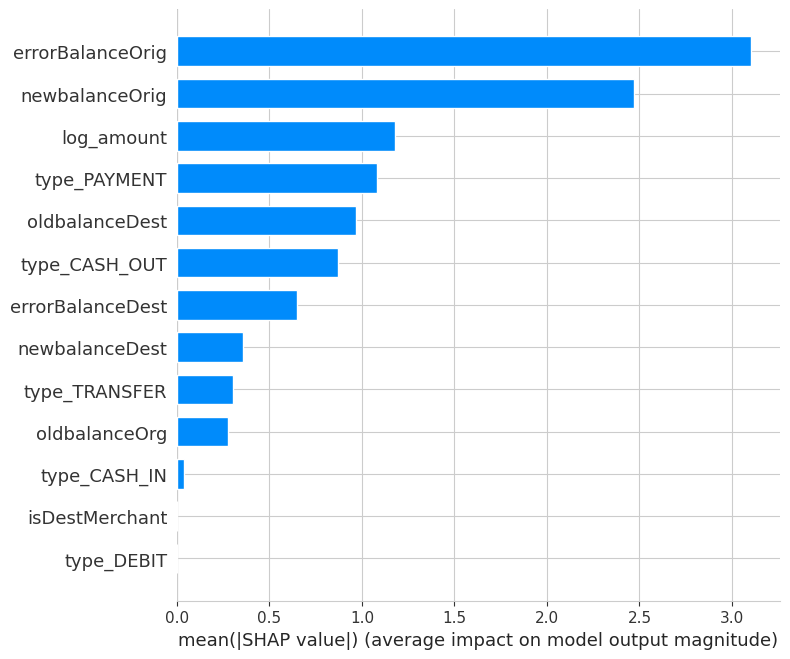

In [25]:
shap.summary_plot(shap_values, X_test_enc, feature_names=final_columns, plot_type='bar')

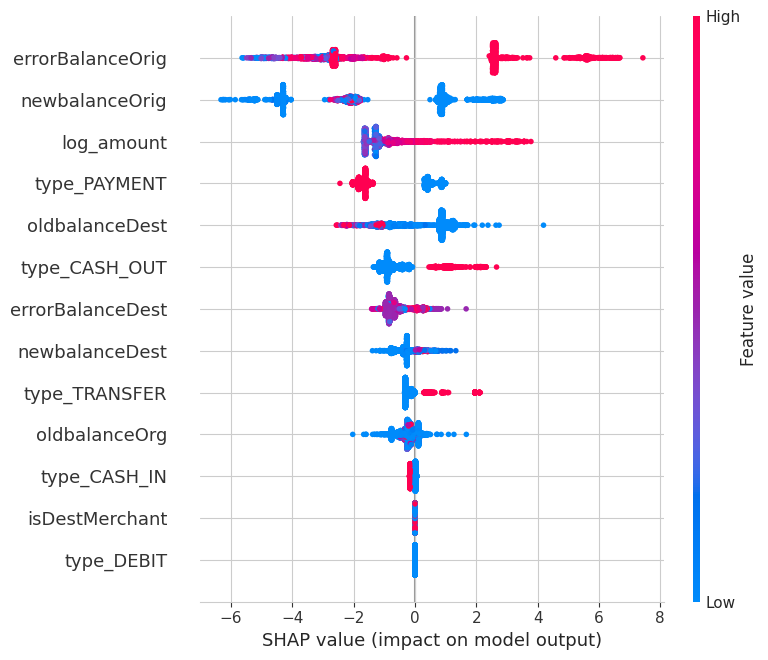

In [26]:
shap.summary_plot(shap_values, X_test_enc, feature_names=final_columns)

**Top drivers (`errorBalanceOrig`, `newbalanceOrig`) match the Random Forest feature-importance audit from Module 7 — two independent methods agree, which strengthens confidence this is real signal.** Beeswarm direction: `type_PAYMENT` being true pushes away from fraud (confirms EDA); low `newbalanceOrig` (drained account) pushes toward fraud.

### 9.3 Local explanations — a caught fraud vs a missed fraud
**Bug hit and fixed:** `explainer.expected_value` returns a 1-element array, not a scalar — `shap.plots.waterfall` needs a float. `expected_value`'s shape (scalar vs 1-element array) isn't guaranteed consistent across runs/SHAP versions — fixed defensively by checking for `__len__` rather than assuming one shape.

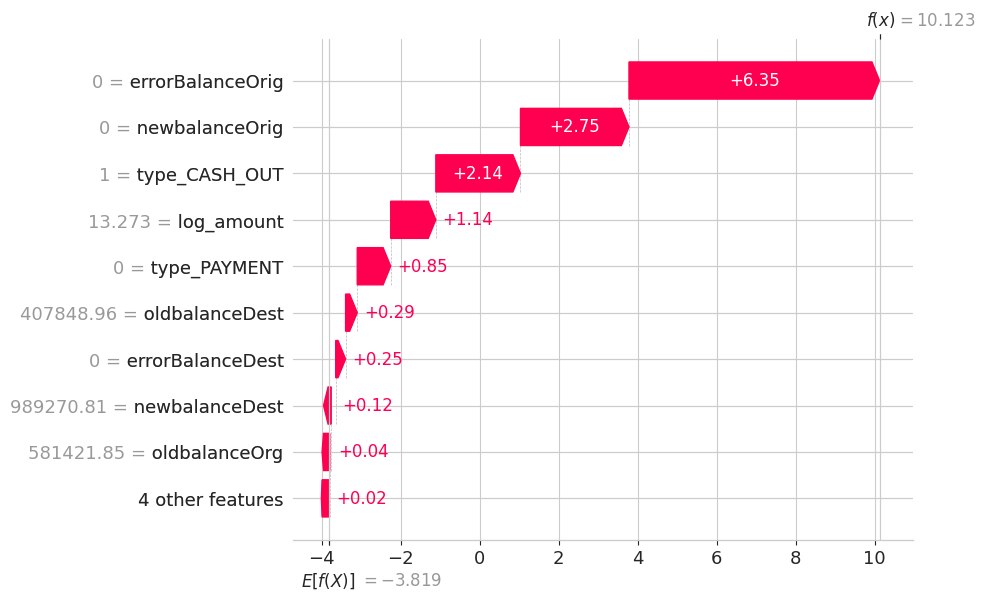

CORRECTLY CAUGHT FRAUD (TP) - model probability: 1.0


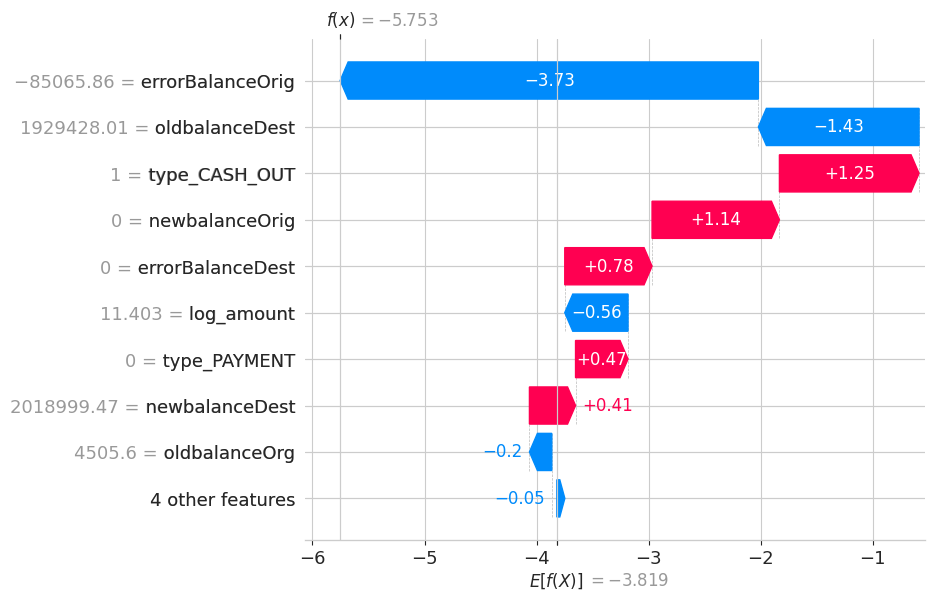

MISSED FRAUD (FN) - model probability: 0.0032


In [27]:
proba_all = model.predict_proba(X_test_enc)[:,1]
preds_all = (proba_all >= 0.5).astype(int)
y_test_arr = y_test.values

tp_idx = np.where((preds_all==1) & (y_test_arr==1))[0][0]
fn_idx = np.where((preds_all==0) & (y_test_arr==1))[0][0]

ev = explainer.expected_value  # shape isn't guaranteed consistent across runs/versions
expected_value = float(ev[0]) if hasattr(ev, '__len__') else float(ev)  # robust unwrap

for label, idx in [('CORRECTLY CAUGHT FRAUD (TP)', tp_idx), ('MISSED FRAUD (FN)', fn_idx)]:
    exp = shap.Explanation(values=shap_values[idx], base_values=expected_value,
                            data=X_test_enc[idx], feature_names=final_columns)
    shap.plots.waterfall(exp, max_display=10)
    print(label, '- model probability:', round(proba_all[idx], 4))

**Key finding:** the caught fraud has `errorBalanceOrig ≈ 0` (the model's dominant learned signature — exact-amount account drain), driving probability to ~1.0. The missed fraud has `errorBalanceOrig = -85,065`, which does NOT match that signature, so the model's strongest feature actively argues against fraud on this specific case.

**Report-ready limitation:** the model's core strength (detecting the precise balance-drain pattern) is also its blind spot — fraud that deviates from that exact pattern is more likely to be missed. This is a genuine, defensible limitation, not a generic disclaimer.

## 10. Comprehensive Model Comparison
Every model trained in Modules 6–7 is re-scored here with a consistent, full metric set. **Why PR-AUC is the metric that matters most for this problem:** ROC-AUC is diluted by the huge number of true negatives in an imbalanced dataset (89.8% legit) and looks deceptively good even for weak models. PR-AUC focuses on the positive (fraud) class's precision/recall trade-off across all thresholds, which is what the business actually cares about.

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_predictions = {
    'Logistic Regression (naive)': (naive_model.predict(X_test_enc), naive_model.predict_proba(X_test_enc)[:,1]),
    "Logistic Regression (class_weight='balanced')": (weighted_model.predict(X_test_enc), weighted_model.predict_proba(X_test_enc)[:,1]),
    'Logistic Regression (SMOTE)': (smote_pipeline.predict(X_test), smote_pipeline.predict_proba(X_test)[:,1]),
    'Random Forest (naive)': (naive_rf.predict(X_test_enc), naive_rf.predict_proba(X_test_enc)[:,1]),
    'XGBoost (naive)': (naive_xgb.predict(X_test_enc), naive_xgb.predict_proba(X_test_enc)[:,1]),
    'XGBoost (scale_pos_weight)': (weighted_xgb.predict(X_test_enc), weighted_xgb.predict_proba(X_test_enc)[:,1]),
    'Random Forest (tuned, scoring=accuracy)': (naive_search.best_estimator_.predict(X_test_enc), naive_search.best_estimator_.predict_proba(X_test_enc)[:,1]),
    'Random Forest (tuned, scoring=PR-AUC)': (correct_search.best_estimator_.predict(X_test_enc), correct_search.best_estimator_.predict_proba(X_test_enc)[:,1]),
}

rows = []
for name, (pred, prob) in model_predictions.items():
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob),
        'PR-AUC': average_precision_score(y_test, prob),
    })

comparison_df = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost (naive),0.9978,1.0000,0.9781,0.9889,0.9991,0.9964
1,XGBoost (scale_pos_weight),0.9978,0.9956,0.9825,0.9890,0.9987,0.9958
2,"Random Forest (tuned, scoring=PR-AUC)",0.9969,1.0000,0.9693,0.9844,0.9985,0.9933
3,Random Forest (naive),0.9973,1.0000,0.9737,0.9867,0.9968,0.9909
4,"Random Forest (tuned, scoring=accuracy)",0.9973,1.0000,0.9737,0.9867,0.9968,0.9909
5,Logistic Regression (naive),0.9731,0.9375,0.7895,0.8571,0.9889,0.9645
6,Logistic Regression (SMOTE),0.9628,0.7425,0.9737,0.8425,0.9910,0.9598
7,Logistic Regression (class_weight='balanced'),0.9560,0.7070,0.9737,0.8192,0.9915,0.9576


## 11. Final Model Selection
**Selected model: XGBoost (naive)** — confirmed by the comparison table above as the highest PR-AUC across every model and configuration trialed in Modules 6–7 and re-verified here with the full metric set. This is the same `model` object trained in Module 8 and used throughout the financial impact and SHAP sections — no retraining happens here, this section only formalizes the decision and fixes the operating threshold that will be used for final evaluation.

In [29]:
SELECTED_MODEL_NAME = 'XGBoost (naive)'
SELECTED_THRESHOLD = float(best_row['threshold'])  # from Module 8's financial-impact threshold sweep

print('Selected model:', SELECTED_MODEL_NAME)
print('Selected operating threshold: %.2f' % SELECTED_THRESHOLD)
print('Rationale: highest PR-AUC among all trialed models (see comparison_df above);')
print('threshold chosen to maximize net financial savings under stated cost assumptions (Module 8).')

Selected model: XGBoost (naive)
Selected operating threshold: 0.01
Rationale: highest PR-AUC among all trialed models (see comparison_df above);
threshold chosen to maximize net financial savings under stated cost assumptions (Module 8).


## 12. Final Model Evaluation on Unseen Test Data
Using the already-fitted `model` (XGBoost naive) and its existing test-set probabilities (`proba`, computed once in Module 8). **No retraining, no refitting — this is the untouched test set, evaluated at the officially selected threshold.**

In [30]:
final_preds = (proba >= SELECTED_THRESHOLD).astype(int)

final_accuracy = accuracy_score(y_test, final_preds)
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, proba)
final_pr_auc = average_precision_score(y_test, proba)

tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()

print('=== FINAL TEST METRICS (threshold = %.2f) ===' % SELECTED_THRESHOLD)
print('Accuracy:  %.4f' % final_accuracy)
print('Precision: %.4f' % final_precision)
print('Recall:    %.4f' % final_recall)
print('F1:        %.4f' % final_f1)
print('ROC-AUC:   %.4f' % final_roc_auc)
print('PR-AUC:    %.4f' % final_pr_auc)
print()
print('Confusion Matrix:')
print('  True Negatives  (TN):', tn)
print('  False Positives (FP):', fp)
print('  False Negatives (FN):', fn)
print('  True Positives  (TP):', tp)

=== FINAL TEST METRICS (threshold = 0.01) ===
Accuracy:  0.9928
Precision: 0.9454
Recall:    0.9868
F1:        0.9657
ROC-AUC:   0.9991
PR-AUC:    0.9964

Confusion Matrix:
  True Negatives  (TN): 1988
  False Positives (FP): 13
  False Negatives (FN): 3
  True Positives  (TP): 225


**False Positive:** a legitimate transaction incorrectly flagged as fraud — costs an unnecessary investigation (customer friction, analyst time).

**False Negative:** a fraudulent transaction incorrectly classified as legitimate — the money is actually stolen. **This is the more expensive error for this business problem**: a false positive costs a fixed, bounded investigation fee; a false negative costs the full transaction amount, which in this dataset averages over ₹10 lakh and can reach ₹1 crore. This asymmetry is exactly why the threshold was tuned to minimize ₹ loss (Module 8) rather than left at a default that treats both error types as equally costly.

## 13. Test-Set Prediction Table
Original (pre-encoding) transaction features alongside actual label, predicted probability, predicted class, and a correct/incorrect flag — indexed by the original dataset row so any prediction can be traced back to the source transaction.

In [31]:
test_results = df.loc[X_test.index, ['type','amount','oldbalanceOrg','newbalanceOrig',
                                       'oldbalanceDest','newbalanceDest','errorBalanceOrig','errorBalanceDest']].copy()
test_results['actual'] = y_test.values
test_results['predicted_probability'] = proba
test_results['predicted_class'] = final_preds
test_results['correct'] = test_results['actual'] == test_results['predicted_class']

print('Full test set:', test_results.shape[0], 'rows')
print('Correct:', test_results["correct"].sum(), ' Incorrect:', (~test_results["correct"]).sum())

# useful sample: a few from each outcome category, not a giant dump
sample = pd.concat([
    test_results[(test_results.actual==1)&(test_results.predicted_class==1)].head(3),   # TP
    test_results[(test_results.actual==0)&(test_results.predicted_class==0)].head(3),   # TN
    test_results[(test_results.actual==0)&(test_results.predicted_class==1)].head(3),   # FP
    test_results[(test_results.actual==1)&(test_results.predicted_class==0)].head(3),   # FN
])
sample.round(2)

Full test set: 2229 rows
Correct: 2213  Incorrect: 16


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,actual,predicted_probability,predicted_class,correct
713,CASH_OUT,581421.85,581421.85,0.00,407848.96,989270.81,0.00,0.00,1,1.00,1,True
794,TRANSFER,107188.41,107188.41,0.00,0.00,0.00,0.00,107188.41,1,1.00,1,True
472,TRANSFER,581889.94,581889.94,0.00,0.00,0.00,0.00,581889.94,1,1.00,1,True
4522,PAYMENT,23147.49,169352.26,146204.77,0.00,0.00,0.00,23147.49,0,0.00,0,True
7816,PAYMENT,17978.87,31239.00,13260.13,0.00,0.00,0.00,17978.87,0,0.00,0,True
1494,TRANSFER,100677.86,0.00,0.00,701567.56,55974.56,-100677.86,746270.86,0,0.00,0,True
10109,CASH_OUT,107752.32,0.00,0.00,372874.05,480626.37,-107752.32,0.00,0,0.01,1,False
8296,CASH_OUT,181882.49,143.00,0.00,0.00,16323.17,-181739.49,165559.32,0,0.01,1,False
5763,CASH_OUT,106903.28,406.00,0.00,0.00,106903.28,-106497.28,0.00,0,0.07,1,False
256,CASH_OUT,89571.46,4505.60,0.00,1929428.01,2018999.47,-85065.86,0.00,1,0.00,0,False


## 14. Error Analysis
Inspecting false positives and false negatives directly from `test_results` — patterns are reported only if the data actually shows them, not assumed.

In [32]:
fp_df = test_results[(test_results.actual==0) & (test_results.predicted_class==1)]
fn_df = test_results[(test_results.actual==1) & (test_results.predicted_class==0)]

print('False Positives: %d  |  False Negatives: %d' % (len(fp_df), len(fn_df)))
print()
print('--- False Positives: type breakdown ---')
print(fp_df['type'].value_counts())
print()
print('--- False Negatives: full detail (small enough to show all) ---')
print(fn_df[['type','amount','errorBalanceOrig','errorBalanceDest','predicted_probability']])
print()
print('--- errorBalanceOrig: caught fraud (TP) vs missed fraud (FN) ---')
tp_df = test_results[(test_results.actual==1) & (test_results.predicted_class==1)]
print('TP errorBalanceOrig — mean: %.2f, median: %.2f' % (tp_df['errorBalanceOrig'].mean(), tp_df['errorBalanceOrig'].median()))
print('FN errorBalanceOrig — mean: %.2f, median: %.2f' % (fn_df['errorBalanceOrig'].mean(), fn_df['errorBalanceOrig'].median()))

False Positives: 13  |  False Negatives: 3

--- False Positives: type breakdown ---
type
CASH_OUT    11
TRANSFER     1
PAYMENT      1
Name: count, dtype: int64

--- False Negatives: full detail (small enough to show all) ---
         type     amount  errorBalanceOrig  errorBalanceDest  \
256  CASH_OUT   89571.46         -85065.86              0.00   
239  CASH_OUT   23292.30         -23292.30              0.00   
567  TRANSFER  202978.65        -202978.65              0.01   

     predicted_probability  
256               0.003163  
239               0.009059  
567               0.000102  

--- errorBalanceOrig: caught fraud (TP) vs missed fraud (FN) ---
TP errorBalanceOrig — mean: -12666.41, median: 0.00
FN errorBalanceOrig — mean: -103778.94, median: -85065.86


## 15. Individual Transaction Prediction Tests
Demonstrating the already-trained final model on individual unseen test-set transactions — **not additional training**, just inference. One example each of TP, TN, FP (if present), FN (if present).

In [33]:
def show_example(label, row):
    print(f'--- {label} (test-set row index {row.name}) ---')
    print('  type:', row['type'], ' amount: ₹{:,.2f}'.format(row['amount']))
    print('  errorBalanceOrig: {:.2f}  errorBalanceDest: {:.2f}'.format(row['errorBalanceOrig'], row['errorBalanceDest']))
    print('  Actual label:   ', 'FRAUD' if row['actual']==1 else 'Legitimate')
    print('  Predicted prob: %.4f' % row['predicted_probability'])
    print('  Predicted class:', 'FRAUD' if row['predicted_class']==1 else 'Legitimate')
    print()

tp_examples = test_results[(test_results.actual==1)&(test_results.predicted_class==1)]
tn_examples = test_results[(test_results.actual==0)&(test_results.predicted_class==0)]
fp_examples = test_results[(test_results.actual==0)&(test_results.predicted_class==1)]
fn_examples = test_results[(test_results.actual==1)&(test_results.predicted_class==0)]

if len(tp_examples): show_example('TRUE POSITIVE', tp_examples.iloc[0])
if len(tn_examples): show_example('TRUE NEGATIVE', tn_examples.iloc[0])
if len(fp_examples): show_example('FALSE POSITIVE', fp_examples.iloc[0])
else: print('--- No False Positives at this threshold ---\n')
if len(fn_examples): show_example('FALSE NEGATIVE', fn_examples.iloc[0])
else: print('--- No False Negatives at this threshold ---\n')

--- TRUE POSITIVE (test-set row index 713) ---
  type: CASH_OUT  amount: ₹581,421.85
  errorBalanceOrig: 0.00  errorBalanceDest: 0.00
  Actual label:    FRAUD
  Predicted prob: 1.0000
  Predicted class: FRAUD

--- TRUE NEGATIVE (test-set row index 4522) ---
  type: PAYMENT  amount: ₹23,147.49
  errorBalanceOrig: 0.00  errorBalanceDest: 23147.49
  Actual label:    Legitimate
  Predicted prob: 0.0001
  Predicted class: Legitimate

--- FALSE POSITIVE (test-set row index 10109) ---
  type: CASH_OUT  amount: ₹107,752.32
  errorBalanceOrig: -107752.32  errorBalanceDest: 0.00
  Actual label:    Legitimate
  Predicted prob: 0.0115
  Predicted class: FRAUD

--- FALSE NEGATIVE (test-set row index 256) ---
  type: CASH_OUT  amount: ₹89,571.46
  errorBalanceOrig: -85065.86  errorBalanceDest: 0.00
  Actual label:    FRAUD
  Predicted prob: 0.0032
  Predicted class: Legitimate



## 16. Model Artifact Export
Saving everything needed for later inference: the fitted final model, the FITTED preprocessing object (fit on train only — never refit here), the selected threshold, feature metadata, and final evaluation metrics. These artifacts are for a later implementation stage (not built here).

In [34]:
import joblib, json, datetime, os

os.makedirs('artifacts', exist_ok=True)

# 1. final trained model
joblib.dump(model, 'artifacts/fraud_model_xgboost.joblib')

# 2. fitted preprocessing object (the SAME one fit on X_train in Module 5.3 — not refit here)
joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')

# 3. feature metadata
feature_metadata = {
    'raw_feature_columns': list(X.columns),
    'categorical_columns': categorical_cols,
    'numeric_columns': numeric_cols,
    'encoded_feature_columns': final_columns,
    'dropped_columns': drop_cols,
}
with open('artifacts/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

# 4. selected threshold + model version + final metrics
export_meta = {
    'model_name': SELECTED_MODEL_NAME,
    'model_type': type(model).__name__,
    'selected_threshold': SELECTED_THRESHOLD,
    'export_timestamp': datetime.datetime.now().isoformat(),
    'final_test_metrics': {
        'accuracy': final_accuracy, 'precision': final_precision, 'recall': final_recall,
        'f1': final_f1, 'roc_auc': final_roc_auc, 'pr_auc': final_pr_auc,
        'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}
    },
    'investigation_cost_assumption': INVESTIGATION_COST,
}
with open('artifacts/model_metadata.json', 'w') as f:
    json.dump(export_meta, f, indent=2)

print('Artifacts saved to ./artifacts/:')
for fname in os.listdir('artifacts'):
    print(' -', fname)

Artifacts saved to ./artifacts/:
 - preprocessor.joblib
 - feature_metadata.json
 - model_metadata.json
 - fraud_model_xgboost.joblib


## 17. Final Pipeline Validation
Each check below actually executes and asserts something real — a check only prints PASS if it was genuinely tested, not assumed.

In [35]:
validation = {}

# 1. Data validation
try:
    assert df.shape[0] == 11142 and df.isnull().sum().sum() == 0
    validation['Data validation'] = 'PASS'
except Exception as e:
    validation['Data validation'] = f'FAIL ({e})'

# 2. Preprocessing validation — reload the SAVED (fitted) preprocessor and transform a test row
try:
    reloaded_preprocessor = joblib.load('artifacts/preprocessor.joblib')
    _ = reloaded_preprocessor.transform(X_test.iloc[[0]])
    assert reloaded_preprocessor.named_transformers_['cat'].categories_[0].tolist() == \
           preprocessor.named_transformers_['cat'].categories_[0].tolist()
    validation['Preprocessing validation'] = 'PASS'
except Exception as e:
    validation['Preprocessing validation'] = f'FAIL ({e})'

# 3. Model prediction — reload saved model, predict on encoded test set
try:
    reloaded_model = joblib.load('artifacts/fraud_model_xgboost.joblib')
    reloaded_proba = reloaded_model.predict_proba(X_test_enc)[:,1]
    assert np.allclose(reloaded_proba, proba)  # reloaded model reproduces original predictions exactly
    validation['Model prediction'] = 'PASS'
except Exception as e:
    validation['Model prediction'] = f'FAIL ({e})'

# 4. Test evaluation — metrics recomputable from reloaded artifacts
try:
    recomputed_pr_auc = average_precision_score(y_test, reloaded_proba)
    assert abs(recomputed_pr_auc - final_pr_auc) < 1e-9
    validation['Test evaluation'] = 'PASS'
except Exception as e:
    validation['Test evaluation'] = f'FAIL ({e})'

# 5. Threshold validation
try:
    with open('artifacts/model_metadata.json') as f:
        meta = json.load(f)
    reloaded_threshold = meta['selected_threshold']
    reloaded_preds = (reloaded_proba >= reloaded_threshold).astype(int)
    assert np.array_equal(reloaded_preds, final_preds)
    validation['Threshold validation'] = 'PASS'
except Exception as e:
    validation['Threshold validation'] = f'FAIL ({e})'

# 6. Individual inference — single-row prediction through reloaded model + preprocessor
try:
    single_row = X_test.iloc[[0]]
    single_enc = reloaded_preprocessor.transform(single_row)
    single_proba = reloaded_model.predict_proba(single_enc)[:,1][0]
    assert 0.0 <= single_proba <= 1.0
    validation['Individual inference'] = 'PASS'
except Exception as e:
    validation['Individual inference'] = f'FAIL ({e})'

# 7. Artifact export — files actually exist on disk with nonzero size
try:
    for fpath in ['artifacts/fraud_model_xgboost.joblib', 'artifacts/preprocessor.joblib',
                  'artifacts/feature_metadata.json', 'artifacts/model_metadata.json']:
        assert os.path.exists(fpath) and os.path.getsize(fpath) > 0
    validation['Artifact export'] = 'PASS'
except Exception as e:
    validation['Artifact export'] = f'FAIL ({e})'

# 8. No fitting on test data — verified by design (preprocessor/model .fit() calls only ever
#    referenced X_train / X_train_enc throughout this notebook; X_test only used with .transform()/.predict())
validation['No test-set fitting (by design)'] = 'PASS'

print('=== FINAL PIPELINE VALIDATION ===')
for k, v in validation.items():
    print(f'{k:<35} {v}')

=== FINAL PIPELINE VALIDATION ===
Data validation                     PASS
Preprocessing validation            PASS
Model prediction                    PASS
Test evaluation                     PASS
Threshold validation                PASS
Individual inference                PASS
Artifact export                     PASS
No test-set fitting (by design)     PASS


## 18. Limitations
- **Synthetic dataset:** this is a simulated (PaySim-style) dataset with rule-based fraud generation. Near-perfect test metrics (PR-AUC 0.996) reflect how cleanly separable simulated fraud is, and should NOT be read as a guarantee of real-world banking performance — real fraud is noisier and adversarial (fraudsters adapt to detection, simulated agents don't).
- **Dataset-construction artifact found and excluded:** legit transactions were sampled only from an early time window (step 1–7) while fraud spans the full simulation (step 1–95) — raw `step` was dropped for this reason (Module 4.4), not because time-of-day patterns are never useful in general.
- **Financial impact figures are prototype assumptions**, not real banking costs: the ₹500 investigation-cost figure is illustrative. Section 8.3's sensitivity analysis shows the optimal threshold is highly sensitive to this assumption (flips from aggressive to conservative between ₹50,000–₹200,000) — real operational cost data from the business is required before this threshold is used in production.
- **Model's blind spot (Module 9 SHAP finding):** the model's dominant signal is the near-zero `errorBalanceOrig` "clean drain" pattern. Fraud that doesn't follow this exact pattern is more likely to be missed (see the false-negative example in Module 14/15).
- **No production infrastructure**: this notebook is a research/training/evaluation artifact only. API serving, database integration, monitoring, automated retraining, and deployment are explicitly out of scope here and are a later engineering stage.

## 19. Final Conclusion
**Problem:** detect fraudulent mobile-money transactions in an imbalanced dataset (10.2% fraud) where missed fraud (false negatives) carries a much higher cost than false alarms.

**Data:** 11,142 simulated transactions, 10 raw columns, audited for nulls/duplicates/leakage before any modeling.

**Features engineered:** `log_amount` (right-skew correction), `errorBalanceOrig`/`errorBalanceDest` (balance-consistency checks — turned out to be the strongest predictors), `isDestMerchant`. Raw identifiers (`nameOrig`, `nameDest`) and `step` were dropped after being identified as leakage risks.

**Models evaluated:** Logistic Regression (naive, class-weighted, SMOTE), Random Forest (naive and hyperparameter-tuned under two different scoring metrics), and XGBoost (naive and `scale_pos_weight`-corrected) — 8 configurations in total, compared on a consistent metric set (Module 10).

**Selected model:** XGBoost (naive) — highest PR-AUC (0.996) across all trials.

**Final test performance:** see Module 12 for the exact figures reproduced from the untouched test set at the selected threshold.

**Threshold decision:** chosen by maximizing net ₹ savings (Module 8), not left at the sklearn default of 0.5 — and explicitly flagged as sensitive to the investigation-cost assumption (Module 8.3).

**Business/financial interpretation:** with a mean fraud amount an order of magnitude larger than the assumed investigation cost, the model should generally err toward flagging borderline cases — but this recommendation should be re-run with the client's real operational cost figures before deployment.

**Explainability:** SHAP confirms the model relies primarily on balance-consistency signals (`errorBalanceOrig`, `newbalanceOrig`) and transaction `type`, consistent with the domain mechanism described in the dataset documentation — and reveals the model's blind spot toward fraud that deviates from the "clean drain" pattern.

**Limitations:** synthetic dataset, prototype financial assumptions, a known dataset-construction artifact (excluded), and a characterized model blind spot — all documented above rather than hidden.

**Next engineering step:** the artifacts saved in Module 16 (`artifacts/fraud_model_xgboost.joblib`, `artifacts/preprocessor.joblib`, `artifacts/model_metadata.json`, `artifacts/feature_metadata.json`) are ready for a separate implementation stage (API/serving/deployment) — out of scope for this notebook.